# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('sample_data/bank-additional-full.csv', sep = ';')

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
df.shape

(41188, 21)

In [ ]:
df.y.value_counts(normalize=True).round(3)

,proportion
y,
no,0.887
yes,0.113


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

The business objective of this task is to build a model that can predict whether a client will subscribe to a term deposit
based on the provided bank marketing data. This prediction can help the banking institution to identify potential customers
and optimize their marketing campaigns, ultimately increasing the success rate of term deposit subscriptions.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

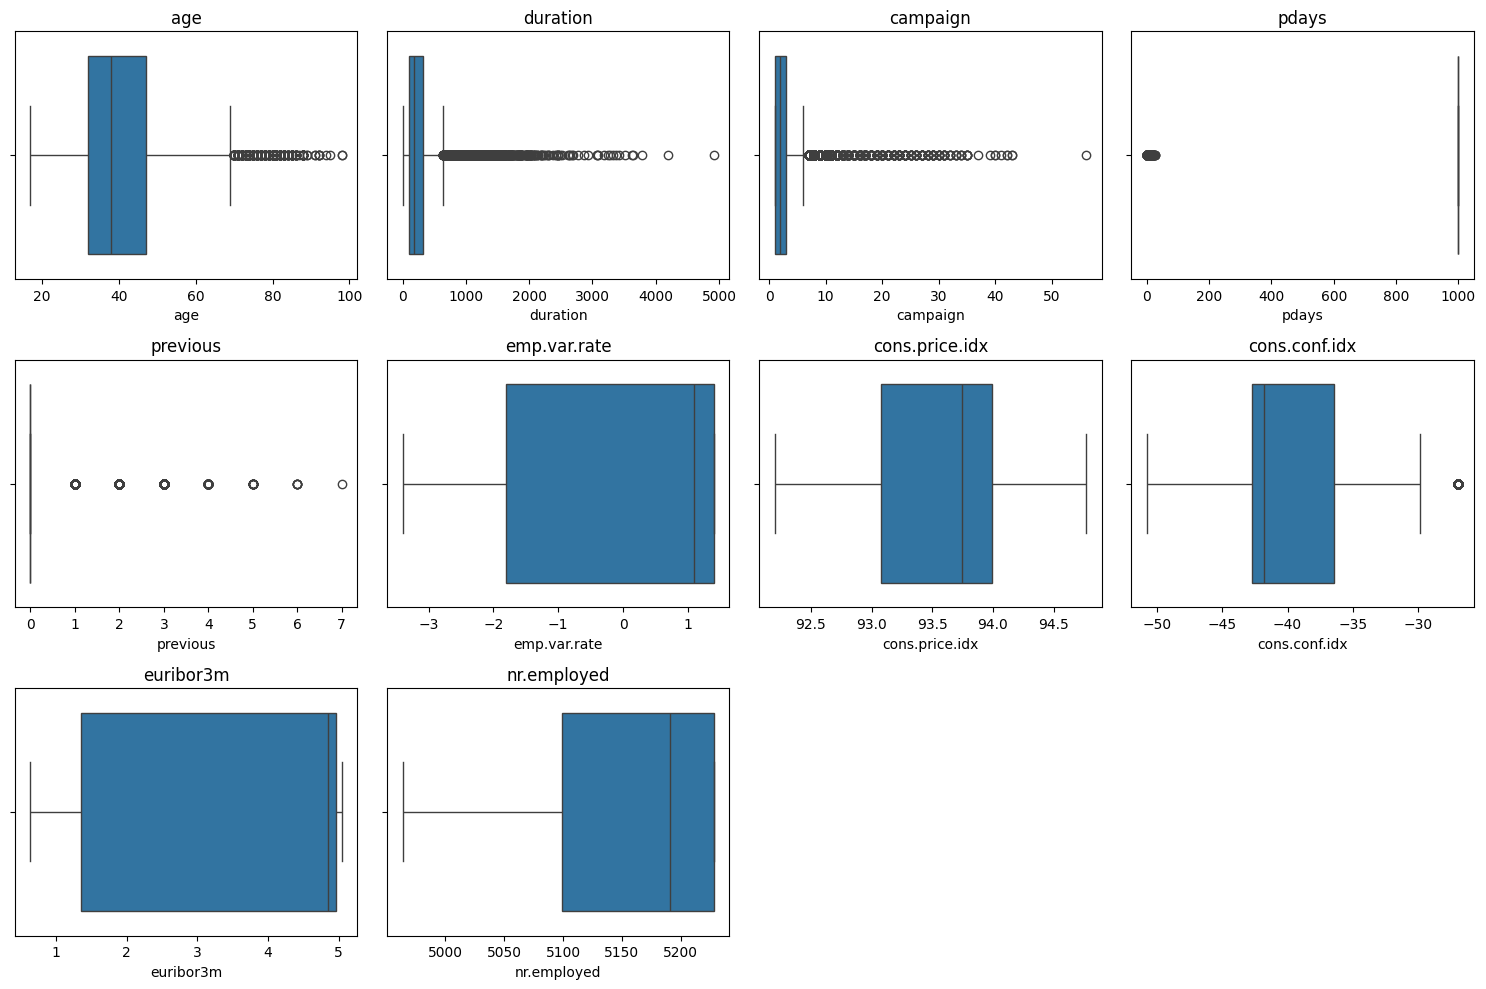

In [ ]:


# Select only numerical columns for outlier detection
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Create box plots for each numerical column to visualize outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

The duration feature in that dataset is kind of a cheat code. It tells you how long the marketing call lasted, and turns out,
longer calls usually mean the person said yes to the offer. If the call was super short or zero seconds, it’s almost always a no.

But here’s the catch: you only know the duration after the call happens. So if you’re trying to build a model to predict whether
someone will say yes before you call them, using duration is like peeking at the answer key. It gives your model unfair superpowers
that wouldn’t exist in the real world.


In [ ]:
# Remove the 'duration' column
df = df.drop('duration', axis=1)

# Display the head of the DataFrame
display(df.head())

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
df.select_dtypes(include = "object").agg(["nunique"])

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
nunique,12,4,8,3,3,3,2,10,5,3,2


<Figure size 1000x600 with 0 Axes>

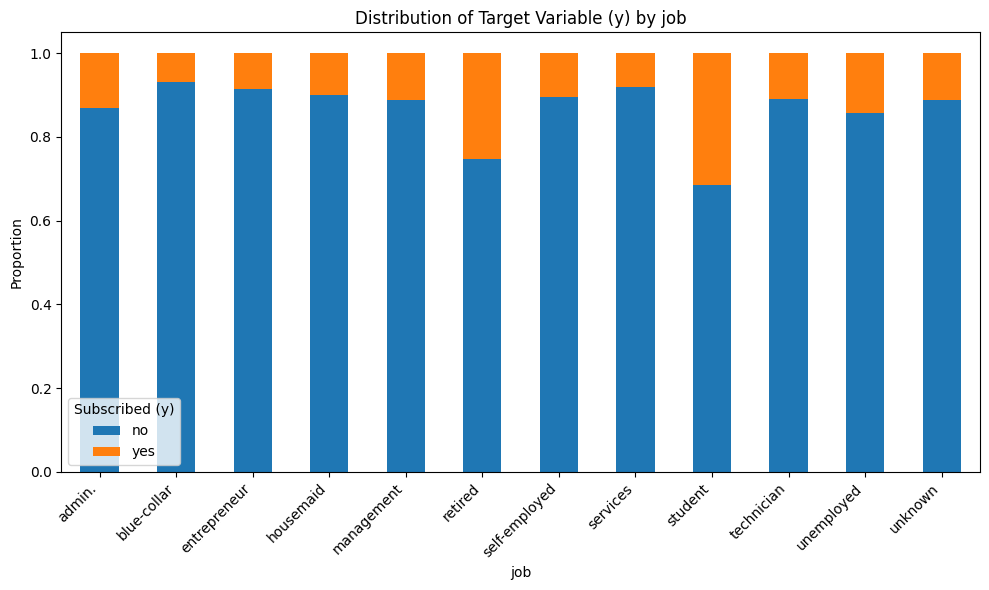

<Figure size 1000x600 with 0 Axes>

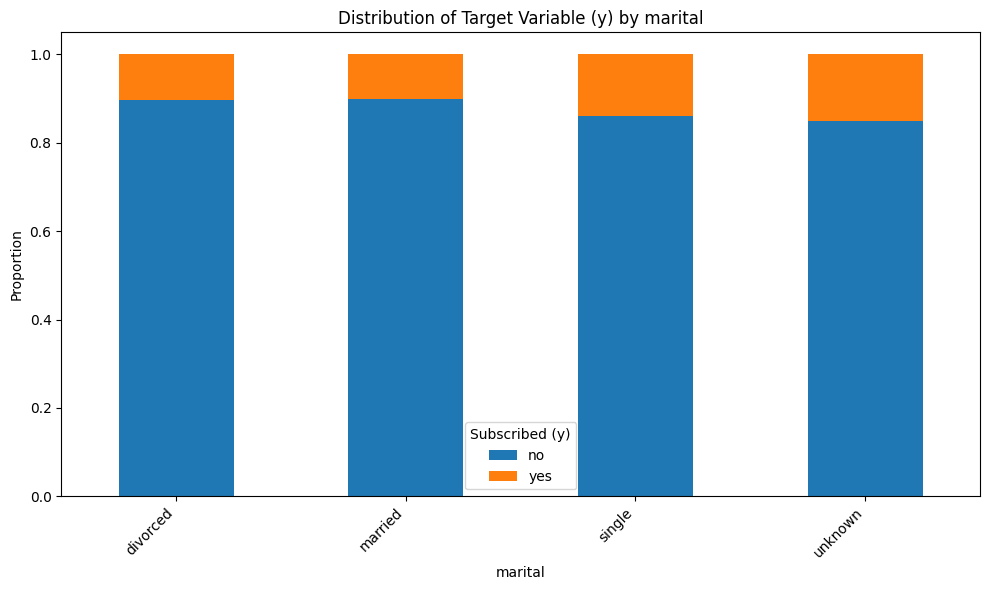

<Figure size 1000x600 with 0 Axes>

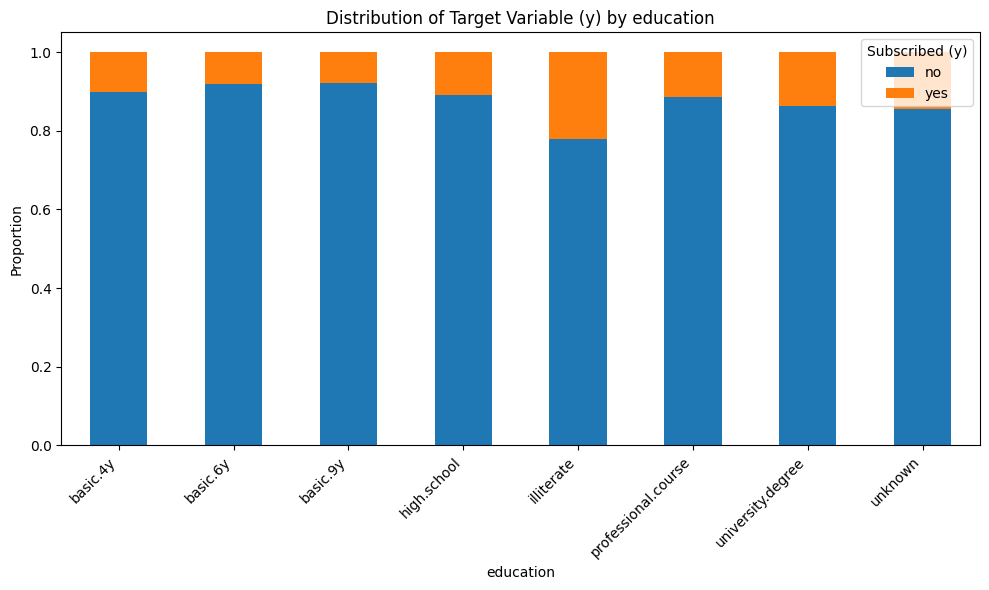

<Figure size 1000x600 with 0 Axes>

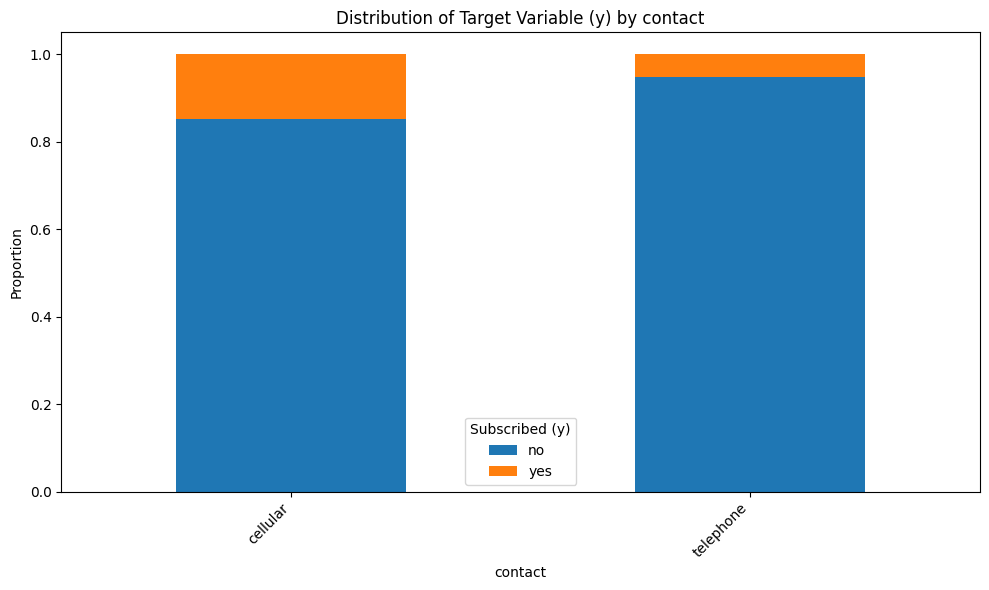

<Figure size 1000x600 with 0 Axes>

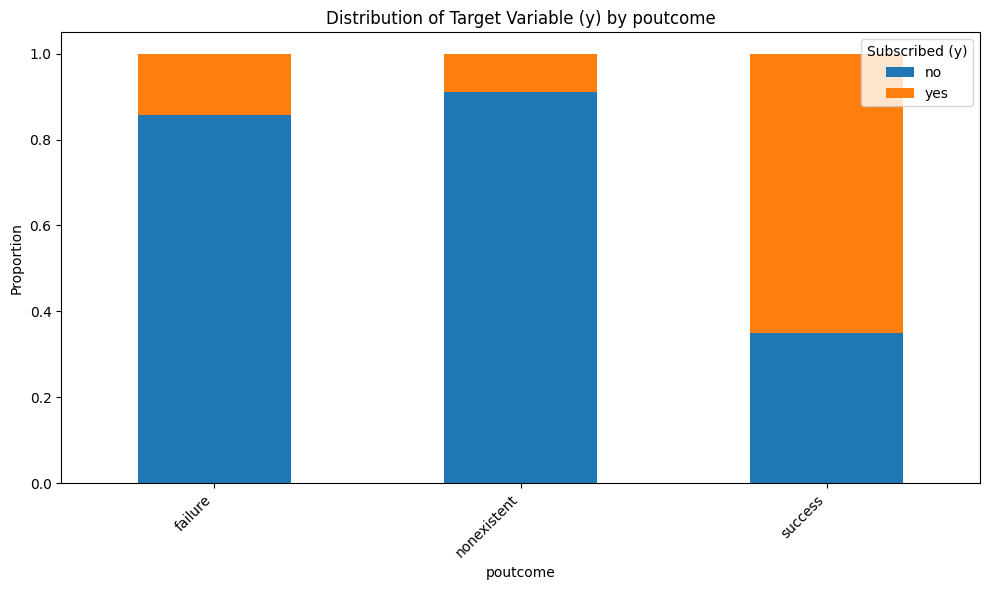

In [ ]:
 #Select some categorical and their relationship with the target variable 'y'
categorical_features = ['job', 'marital', 'education', 'contact', 'poutcome']

# Create stacked bar for each categorical feature against the target variable 'y'
for col in categorical_features:
    plt.figure(figsize=(10, 6))
    ct = pd.crosstab(df[col], df['y'], normalize='index')
    ct.plot(kind='bar', stacked=True, figsize=(10, 6))
    plt.title(f'Distribution of Target Variable (y) by {col}')
    plt.xlabel(col)
    plt.ylabel('Proportion')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Subscribed (y)')
    plt.tight_layout()
    plt.show()

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [ ]:
# Select the bank client data features
bank_client_features = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']
X = df[bank_client_features]
y = df['y']

# Perform one-hot encoding on categorical features
X = pd.get_dummies(X, columns=['job', 'marital', 'education', 'default', 'housing', 'loan'], drop_first=True)

# Convert target variable to numerical (0 for 'no', 1 for 'yes')
y = y.apply(lambda x: 1 if x == 'yes' else 0)

print("Prepared Features (X) head:")
display(X.head())
print("\Target Variable (y) head:")
display(y.head())

Prepared Features (X) head:


,age,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,education_illiterate,education_professional.course,education_university.degree,education_unknown,default_unknown,default_yes,housing_unknown,housing_yes,loan_unknown,loan_yes
0,56,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,57,False,False,False,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
2,37,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,40,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,56,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True


\Target Variable (y) head:


,y
0,0
1,0
2,0
3,0
4,0


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (30891, 28)
X_test shape: (10297, 28)
y_train shape: (30891,)
y_test shape: (10297,)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Select numerical columns
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Scaled X_train head:")
display(X_train.head())
print("\nScaled X_test head:")
display(X_test.head())

Scaled X_train head:


,age,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,education_illiterate,education_professional.course,education_university.degree,education_unknown,default_unknown,default_yes,housing_unknown,housing_yes,loan_unknown,loan_yes
549,0.955475,True,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,True,False,True,False
1974,-1.341636,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20992,-0.575932,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1730,-0.958784,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
26913,-1.054497,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False



Scaled X_test head:


,age,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,education_illiterate,education_professional.course,education_university.degree,education_unknown,default_unknown,default_yes,housing_unknown,housing_yes,loan_unknown,loan_yes
32884,1.625466,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
3169,1.434040,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,False,False,True,False,False
32206,-0.671645,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9403,-0.384506,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
14020,-1.245923,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [ ]:
baseline_accuracy = y_train.value_counts(normalize=True).max()
print(f"Baseline Accuracy (by predicting the majority class): {baseline_accuracy:.4f}")

Baseline Accuracy (by predicting the majority class): 0.8871


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [ ]:
from sklearn.linear_model import LogisticRegression
import time


log_reg_model = LogisticRegression(random_state=42, max_iter=1000)

# Record training time
start_time = time.time()
log_reg_model.fit(X_train, y_train)
log_reg_train_time = time.time() - start_time

### Problem 9: Score the Model

What is the accuracy of your model?

In [ ]:
from sklearn.metrics import accuracy_score

# Predict on the training and test sets
y_train_pred = log_reg_model.predict(X_train)
y_test_pred = log_reg_model.predict(X_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Logistic Regression Train Accuracy: {train_accuracy:.4f}")
print(f"Logistic Regression Test Accuracy: {test_accuracy:.4f}")

Logistic Regression Train Accuracy: 0.8871
Logistic Regression Test Accuracy: 0.8880


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import time
from sklearn.metrics import accuracy_score

# Instantiate the KNN model
knn_model = KNeighborsClassifier()

# Record training time
start_time = time.time()
knn_model.fit(X_train, y_train)
knn_train_time = time.time() - start_time

# Predict on the training and test sets
y_train_pred_knn = knn_model.predict(X_train)
y_test_pred_knn = knn_model.predict(X_test)

# Calculate accuracy
knn_train_accuracy = accuracy_score(y_train, y_train_pred_knn)
knn_test_accuracy = accuracy_score(y_test, y_test_pred_knn)

print(f"KNN Train Time: {knn_train_time:.4f} seconds")
print(f"KNN Train Accuracy: {knn_train_accuracy:.4f}")
print(f"KNN Test Accuracy: {knn_test_accuracy:.4f}")

KNN Train Time: 0.0154 seconds
KNN Train Accuracy: 0.8895
KNN Test Accuracy: 0.8768


In [ ]:
from sklearn.tree import DecisionTreeClassifier
import time
from sklearn.metrics import accuracy_score

# Instantiate the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Record training time
start_time = time.time()
dt_model.fit(X_train, y_train)
dt_train_time = time.time() - start_time

# Predict on the training and test sets
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)

# Calculate accuracy
dt_train_accuracy = accuracy_score(y_train, y_train_pred_dt)
dt_test_accuracy = accuracy_score(y_test, y_test_pred_dt)

print(f"Decision Tree Train Time: {dt_train_time:.4f} seconds")
print(f"Decision Tree Train Accuracy: {dt_train_accuracy:.4f}")
print(f"Decision Tree Test Accuracy: {dt_test_accuracy:.4f}")

Decision Tree Train Time: 0.1029 seconds
Decision Tree Train Accuracy: 0.9170
Decision Tree Test Accuracy: 0.8644


In [ ]:
from sklearn.svm import SVC

# Instantiate the SVM model

svm_model = SVC(random_state=42, probability=False)

# Record training time
start_time = time.time()
svm_model.fit(X_train, y_train)
svm_train_time = time.time() - start_time

# Predict on the training and test sets
y_train_pred_svm = svm_model.predict(X_train)
y_test_pred_svm = svm_model.predict(X_test)

# Calculate accuracy
svm_train_accuracy = accuracy_score(y_train, y_train_pred_svm)
svm_test_accuracy = accuracy_score(y_test, y_test_pred_svm)

print(f"SVM Train Time: {svm_train_time:.4f} seconds")
print(f"SVM Train Accuracy: {svm_train_accuracy:.4f}")
print(f"SVM Test Accuracy: {svm_test_accuracy:.4f}")

SVM Train Time: 70.6062 seconds
SVM Train Accuracy: 0.8878
SVM Test Accuracy: 0.8882


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.

- More feature engineering and exploration.  For example, should we keep the gender feature?  Why or why not?
- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [ ]:
print("Distribution of predicted 'y' for Logistic Regression:")
display(pd.Series(y_test_pred).value_counts(normalize=True).round(3))

print("\nDistribution of predicted 'y' for KNN:")
display(pd.Series(y_test_pred_knn).value_counts(normalize=True).round(3))

print("\nDistribution of predicted 'y' for Decision Tree:")
display(pd.Series(y_test_pred_dt).value_counts(normalize=True).round(3))

print("\nDistribution of predicted 'y' for SVM:")
display(pd.Series(y_test_pred_svm).value_counts(normalize=True).round(3))

Distribution of predicted 'y' for Logistic Regression:


,proportion
0,1.0



Distribution of predicted 'y' for KNN:


,proportion
0,0.975
1,0.025



Distribution of predicted 'y' for Decision Tree:


,proportion
0,0.958
1,0.042



Distribution of predicted 'y' for SVM:


,proportion
0,0.999
1,0.001


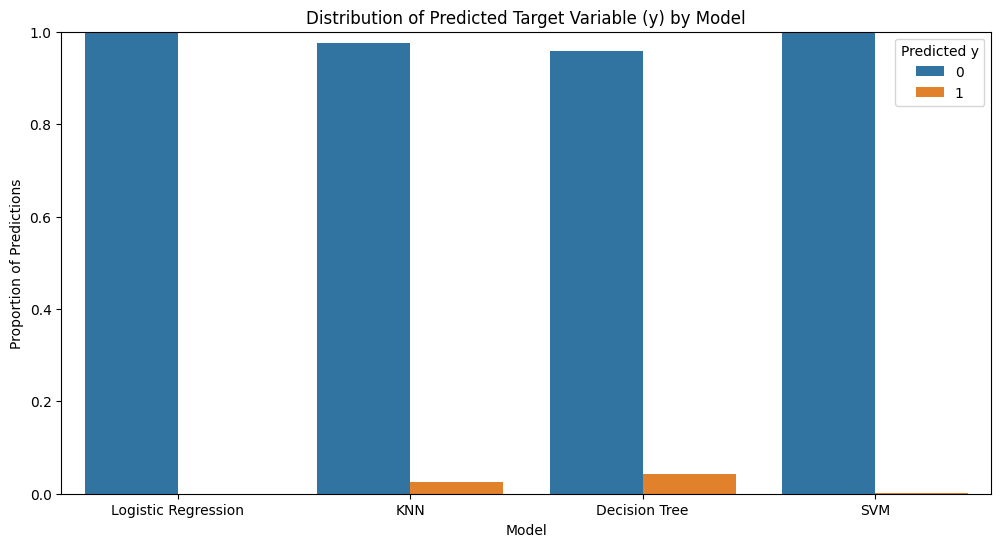

In [ ]:


# Get the predicted y values for each model
predictions = {
    'Logistic Regression': y_test_pred,
    'KNN': y_test_pred_knn,
    'Decision Tree': y_test_pred_dt,
    'SVM': y_test_pred_svm
}

# Create a DataFrame to hold the predicted value counts for plotting
predicted_counts = pd.DataFrame()

for model_name, y_pred in predictions.items():
    counts = pd.Series(y_pred).value_counts(normalize=True).reset_index()
    counts.columns = ['Predicted_y', 'Proportion']
    counts['Model'] = model_name
    predicted_counts = pd.concat([predicted_counts, counts], ignore_index=True)

# Plot the distribution of predicted y values for each model
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Proportion', hue='Predicted_y', data=predicted_counts)
plt.title('Distribution of Predicted Target Variable (y) by Model')
plt.ylabel('Proportion of Predictions')
plt.xlabel('Model')
plt.legend(title='Predicted y')
plt.ylim(0, 1) # Ensure the y-axis goes from 0 to 1 for proportions
plt.show()



Essentially, the models prioritize achieving high accuracy on the dominant 'no' class, at the expense of
 correctly identifying the less frequent 'yes' class. This is why metrics like Precision, Recall, and F1-score are crucial
 for evaluating performance on imbalanced datasets, as they specifically highlight how well the model performs on the minority class.
The low recall and F1-scores for the initial Logistic Regression and SVM models confirm their inability to




In [ ]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score , roc_auc_score

# Calculate metrics for Initial Logistic Regression
y_test_pred_log_reg = log_reg_model.predict(X_test)
accuracy_log_reg = accuracy_score(y_test, y_test_pred_log_reg)
precision_log_reg = precision_score(y_test, y_test_pred_log_reg)
recall_log_reg = recall_score(y_test, y_test_pred_log_reg)
f1_log_reg = f1_score(y_test, y_test_pred_log_reg)

roc_auc_log_reg = roc_auc_score(y_test, log_reg_model.predict_proba(X_test)[:, 1])


# Calculate metrics for Initial KNN
y_test_pred_knn = knn_model.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_test_pred_knn)
precision_knn = precision_score(y_test, y_test_pred_knn)
recall_knn = recall_score(y_test, y_test_pred_knn)
f1_knn = f1_score(y_test, y_test_pred_knn)
roc_auc_knn = roc_auc_score(y_test, knn_model.predict_proba(X_test)[:, 1])


# Calculate metrics for Initial Decision Tree
y_test_pred_dt = dt_model.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_test_pred_dt)
precision_dt = precision_score(y_test, y_test_pred_dt)
recall_dt = recall_score(y_test, y_test_pred_dt)
f1_dt = f1_score(y_test, y_test_pred_dt)

roc_auc_dt = roc_auc_score(y_test, dt_model.predict_proba(X_test)[:, 1])


# Calculate metrics for Initial SVM
y_test_pred_svm = svm_model.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_test_pred_svm)
precision_svm = precision_score(y_test, y_test_pred_svm)
recall_svm = recall_score(y_test, y_test_pred_svm)
f1_svm = f1_score(y_test, y_test_pred_svm)
roc_auc_svm = "(probability=False)"



# Create a DataFrame to store the metrics
initial_results = {
    'Model': ['Initial Logistic Regression', 'Initial KNN', 'Initial Decision Tree', 'Initial SVM'],
    'Accuracy': [accuracy_log_reg, accuracy_knn, accuracy_dt, accuracy_svm],
    'Precision': [precision_log_reg, precision_knn, precision_dt, precision_svm],
    'Recall': [recall_log_reg, recall_knn, recall_dt, recall_svm],
    'F1-score': [f1_log_reg, f1_knn, f1_dt, f1_svm],
    'ROC AUC': [roc_auc_log_reg, roc_auc_knn, roc_auc_dt, roc_auc_svm ]
}

initial_results_df = pd.DataFrame(initial_results)

# Display the DataFrame
print("Initial Model Performance Comparison:")
display(initial_results_df)

Initial Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Initial Logistic Regression,0.888026,0.000000,0.000000,0.000000,0.650901
1,Initial KNN,0.876760,0.276923,0.062446,0.101911,0.569899
2,Initial Decision Tree,0.864427,0.221968,0.084128,0.122013,0.574226
3,Initial SVM,0.888220,0.600000,0.005204,0.010318,(probability=False)



We perform hyperparameter tuning to find the best combination of settings (hyperparameters) for our machine learning models.
 Hyperparameters are parameters that are not learned from the data itself but are set before the learning process begins.


### Hyperparameter tuning for logestic regression





In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Define the parameter grid for Logistic Regression
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# Instantiate Logistic Regression model
log_reg = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)

# Instantiate GridSearchCV with the Logistic Regression model and parameter grid
grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, cv=5, scoring='roc_auc')

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_
print(f"Best Hyperparameters for Logistic Regression: {best_params}")

# Train a new Logistic Regression model with the best hyperparameters
best_log_reg_model = LogisticRegression(**best_params, random_state=42, solver='liblinear', max_iter=1000)
best_log_reg_model.fit(X_train, y_train)

# Predict on the test set
y_test_pred_best_log_reg = best_log_reg_model.predict(X_test)

# Evaluate the best model using ROC AUC
roc_auc = roc_auc_score(y_test, best_log_reg_model.predict_proba(X_test)[:, 1])
print(f"Best Logistic Regression Test ROC AUC: {roc_auc:.4f}")

# Evaluate the best model using Accuracy
best_log_reg_test_accuracy = accuracy_score(y_test, y_test_pred_best_log_reg)
print(f"Best Logistic Regression Test Accuracy: {best_log_reg_test_accuracy:.4f}")

Best Hyperparameters for Logistic Regression: {'C': 1, 'penalty': 'l1'}
Best Logistic Regression Test ROC AUC: 0.6513
Best Logistic Regression Test Accuracy: 0.8880


### Hyperparameter tuning for KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

# Define the parameter grid for KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'minkowski']
}

# Instantiate KNN model
knn = KNeighborsClassifier()

# Instantiate GridSearchCV with the KNN model and parameter grid
grid_search_knn = GridSearchCV(estimator=knn, param_grid=param_grid_knn, cv=5, scoring='roc_auc')

# Fit the grid search to the training data
grid_search_knn.fit(X_train, y_train)

# Get the best hyperparameters
best_params_knn = grid_search_knn.best_params_
print(f"Best Hyperparameters for KNN: {best_params_knn}")

# Train a new KNN model with the best hyperparameters
best_knn_model = KNeighborsClassifier(**best_params_knn)
best_knn_model.fit(X_train, y_train)

# Predict on the test set
y_test_pred_best_knn = best_knn_model.predict(X_test)

# Evaluate the best model using ROC AUC
roc_auc_knn = roc_auc_score(y_test, best_knn_model.predict_proba(X_test)[:, 1])
print(f"Best KNN Test ROC AUC: {roc_auc_knn:.4f}")

# Evaluate the best model using Accuracy
best_knn_test_accuracy = accuracy_score(y_test, y_test_pred_best_knn)
print(f"Best KNN Test Accuracy: {best_knn_test_accuracy:.4f}")

Best Hyperparameters for KNN: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
Best KNN Test ROC AUC: 0.5932
Best KNN Test Accuracy: 0.8851


## Hyperparameter tuning for decision tree




In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

# Define the parameter grid for Decision Tree
param_grid_dt = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Instantiate Decision Tree model
dt = DecisionTreeClassifier(random_state=42)

# Instantiate GridSearchCV with the Decision Tree model and parameter grid
grid_search_dt = GridSearchCV(estimator=dt, param_grid=param_grid_dt, cv=5, scoring='roc_auc')

# Fit the grid search to the training data
grid_search_dt.fit(X_train, y_train)

# Get the best hyperparameters
best_params_dt = grid_search_dt.best_params_
print(f"Best Hyperparameters for Decision Tree: {best_params_dt}")

# Train a new Decision Tree model with the best hyperparameters
best_dt_model = DecisionTreeClassifier(**best_params_dt, random_state=42)
best_dt_model.fit(X_train, y_train)

# Predict on the test set
y_test_pred_best_dt = best_dt_model.predict(X_test)

# Evaluate the best model using ROC AUC
roc_auc_dt = roc_auc_score(y_test, best_dt_model.predict_proba(X_test)[:, 1])
print(f"Best Decision Tree Test ROC AUC: {roc_auc_dt:.4f}")

# Evaluate the best model using Accuracy
best_dt_test_accuracy = accuracy_score(y_test, y_test_pred_best_dt)
print(f"Best Decision Tree Test Accuracy: {best_dt_test_accuracy:.4f}")

Best Hyperparameters for Decision Tree: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Decision Tree Test ROC AUC: 0.6328
Best Decision Tree Test Accuracy: 0.8878


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Calculate metrics for Tuned Logistic Regression
y_test_pred_tuned_log_reg = best_log_reg_model.predict(X_test)
accuracy_tuned_log_reg = accuracy_score(y_test, y_test_pred_tuned_log_reg)
precision_tuned_log_reg = precision_score(y_test, y_test_pred_tuned_log_reg)
recall_tuned_log_reg = recall_score(y_test, y_test_pred_tuned_log_reg)
f1_tuned_log_reg = f1_score(y_test, y_test_pred_tuned_log_reg)
roc_auc_tuned_log_reg = roc_auc_score(y_test, best_log_reg_model.predict_proba(X_test)[:, 1])

# Calculate metrics for Tuned KNN
y_test_pred_tuned_knn = best_knn_model.predict(X_test)
accuracy_tuned_knn = accuracy_score(y_test, y_test_pred_tuned_knn)
precision_tuned_knn = precision_score(y_test, y_test_pred_tuned_knn)
recall_tuned_knn = recall_score(y_test, y_test_pred_tuned_knn)
f1_tuned_knn = f1_score(y_test, y_test_pred_tuned_knn)
roc_auc_tuned_knn = roc_auc_score(y_test, best_knn_model.predict_proba(X_test)[:, 1])


# Calculate metrics for Tuned Decision Tree
y_test_pred_tuned_dt = best_dt_model.predict(X_test)
accuracy_tuned_dt = accuracy_score(y_test, y_test_pred_tuned_dt)
precision_tuned_dt = precision_score(y_test, y_test_pred_tuned_dt)
recall_tuned_dt = recall_score(y_test, y_test_pred_tuned_dt)
f1_tuned_dt = f1_score(y_test, y_test_pred_tuned_dt)
roc_auc_tuned_dt = roc_auc_score(y_test, best_dt_model.predict_proba(X_test)[:, 1])




# Create a DataFrame to store the metrics
tuned_results = {
    'Model': ['Tuned Logistic Regression', 'Tuned KNN', 'Tuned Decision Tree'],
    'Accuracy': [accuracy_tuned_log_reg, accuracy_tuned_knn, accuracy_tuned_dt],
    'Precision': [precision_tuned_log_reg, precision_tuned_knn, precision_tuned_dt],
    'Recall': [recall_tuned_log_reg, recall_tuned_knn, recall_tuned_dt],
    'F1-score': [f1_tuned_log_reg, f1_tuned_knn, f1_tuned_dt],
    'ROC AUC': [roc_auc_tuned_log_reg, roc_auc_knn, roc_auc_dt]
}

tuned_results_df = pd.DataFrame(tuned_results)

# Display the DataFrame
print("Tuned Model Performance Comparison:")
display(tuned_results_df)

Tuned Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Tuned Logistic Regression,0.888026,0.000000,0.000000,0.000000,0.651313
1,Tuned KNN,0.885112,0.400000,0.052038,0.092095,0.593188
2,Tuned Decision Tree,0.887831,0.454545,0.008673,0.017021,0.632790


## The low recall and F1-scores for the initial Logistic Regression and SVM models confirm their inability to identify the positive class. Now we visualize it in a graph


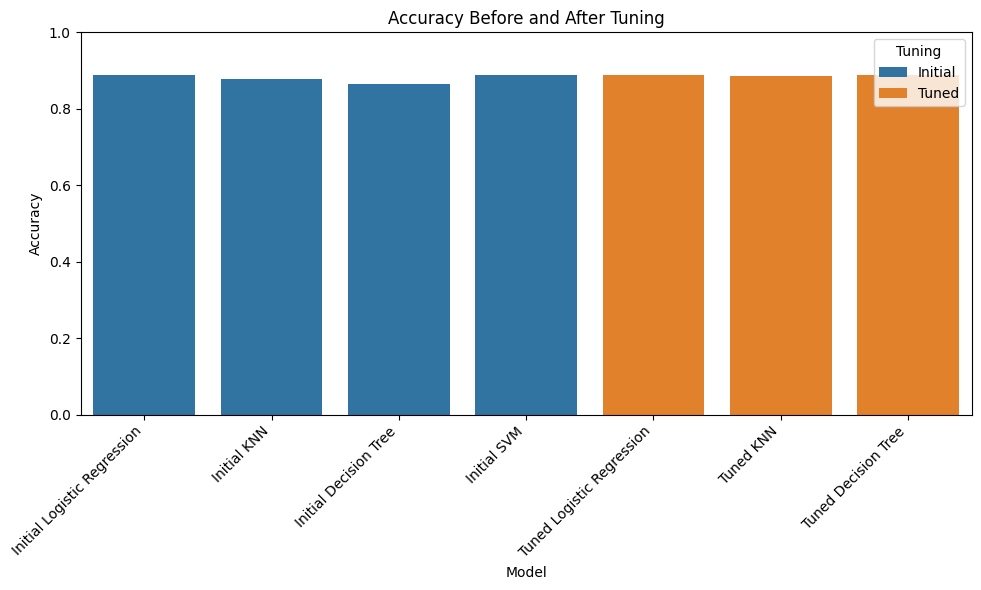

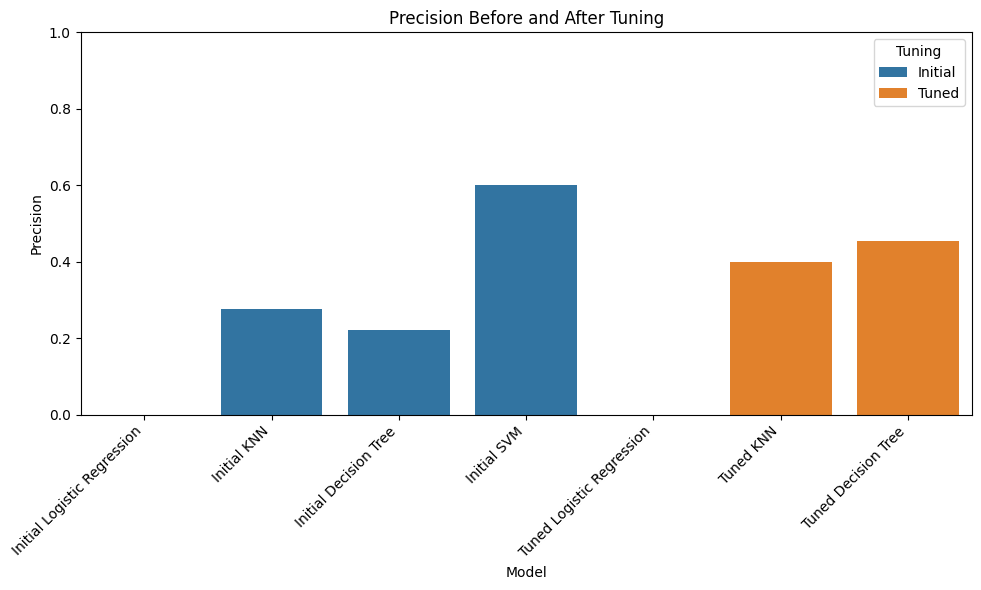

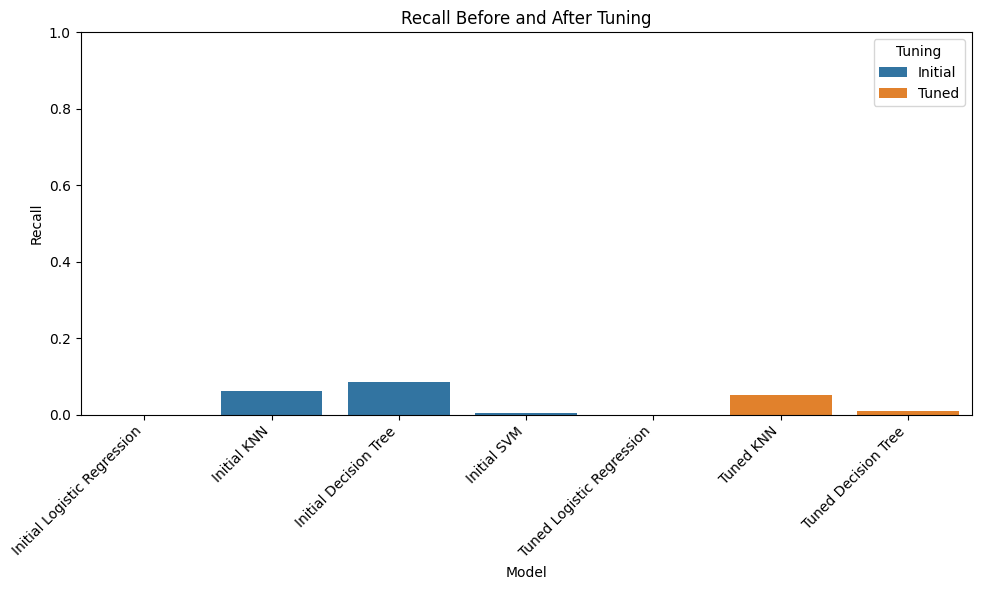

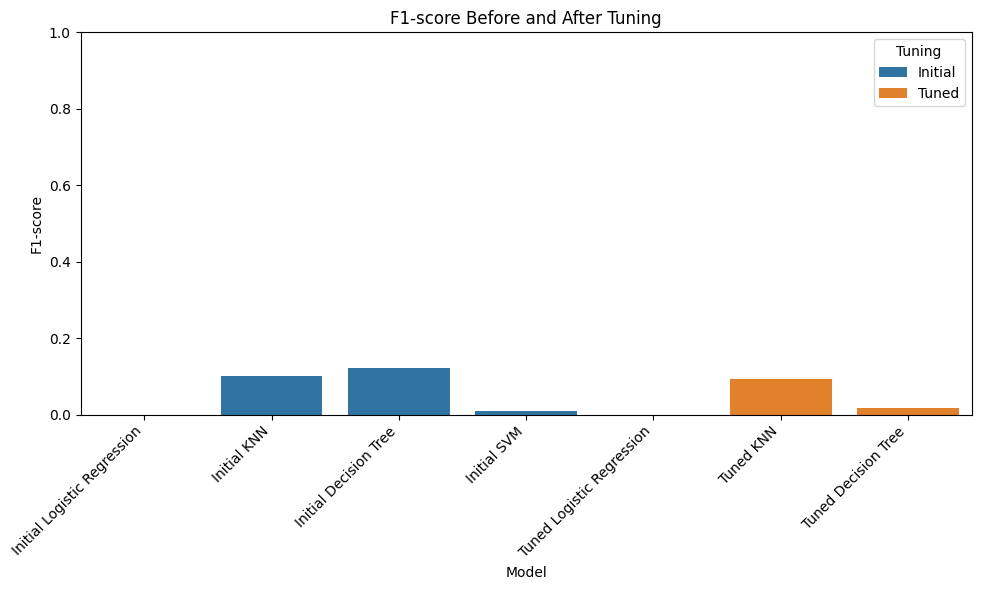

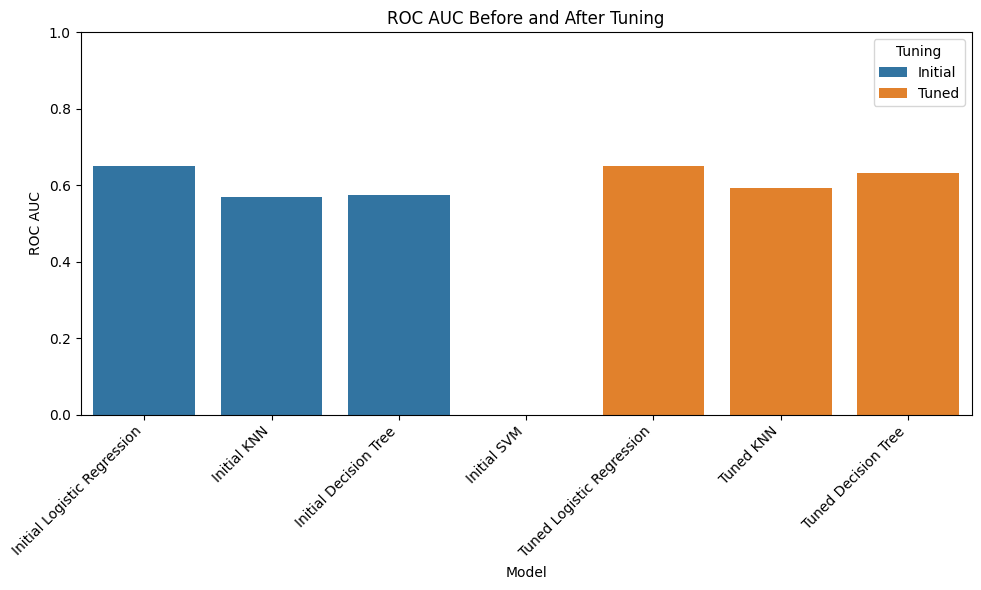

In [ ]:

# Combine initial and tuned results DataFrames
initial_results_df_plot = initial_results_df.copy()
initial_results_df_plot['Tuning'] = 'Initial'

tuned_results_df_plot = tuned_results_df.copy()
tuned_results_df_plot['Tuning'] = 'Tuned'


initial_results_df_plot['ROC AUC'] = pd.to_numeric(initial_results_df_plot['ROC AUC'], errors='coerce')

combined_results_df = pd.concat([initial_results_df_plot, tuned_results_df_plot], ignore_index=True)

# Reshape the DataFrame for plotting (melt)
combined_results_melted = combined_results_df.melt(id_vars=['Model', 'Tuning'],
                                                  value_vars=['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC AUC'],
                                                  var_name='Metric', value_name='Score')

# Create a separate plot for each metric
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC AUC']

for metric in metrics_to_plot:
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Model', y='Score', hue='Tuning', data=combined_results_melted[combined_results_melted['Metric'] == metric])
    plt.title(f'{metric} Before and After Tuning')
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [ ]:
print("Distribution of predicted 'y' for Logistic Regression:")
display(pd.Series(y_test_pred).value_counts(normalize=True).round(3))

print("\nDistribution of predicted 'y' for KNN:")
display(pd.Series(y_test_pred_knn).value_counts(normalize=True).round(3))

print("\nDistribution of predicted 'y' for Decision Tree:")
display(pd.Series(y_test_pred_dt).value_counts(normalize=True).round(3))

print("\nDistribution of predicted 'y' for SVM:")
display(pd.Series(y_test_pred_svm).value_counts(normalize=True).round(3))

Distribution of predicted 'y' for Logistic Regression:


,proportion
0,1.0



Distribution of predicted 'y' for KNN:


,proportion
0,0.975
1,0.025



Distribution of predicted 'y' for Decision Tree:


,proportion
0,0.958
1,0.042



Distribution of predicted 'y' for SVM:


,proportion
0,0.999
1,0.001


In [ ]:
print("Distribution of predicted 'y' for Tuned Logistic Regression:")
display(pd.Series(y_test_pred_tuned_log_reg).value_counts(normalize=True).round(3))

print("\nDistribution of predicted 'y' for Tuned KNN:")
display(pd.Series(y_test_pred_tuned_knn).value_counts(normalize=True).round(3))

print("\nDistribution of predicted 'y' for Tuned Decision Tree:")
display(pd.Series(y_test_pred_tuned_dt).value_counts(normalize=True).round(3))



Distribution of predicted 'y' for Tuned Logistic Regression:


,proportion
0,1.0



Distribution of predicted 'y' for Tuned KNN:


,proportion
0,0.985
1,0.015



Distribution of predicted 'y' for Tuned Decision Tree:


,proportion
0,0.998
1,0.002


##  The tuning data doesn't lead to significant improvements, it suggests that the limitations might be due to the inherent challenges posed by the data (like imbalance) rather than just suboptimal hyperparameter settings. It might be a signal to explore more advanced feature engineering. The best strategies for handling class imbalance are resampling or using class weights.

In [ ]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Check the original distribution of the training data
print("Original training data shape:", X_train.shape, y_train.shape)
print("Original training data class distribution:", Counter(y_train))

# Random Oversampling
ros = RandomOverSampler(random_state=42)
X_resampled_over, y_resampled_over = ros.fit_resample(X_train, y_train)

print("\nTraining data shape after Random Oversampling:", X_resampled_over.shape, y_resampled_over.shape)
print("Training data class distribution after Random Oversampling:", Counter(y_resampled_over))

# Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_resampled_under, y_resampled_under = rus.fit_resample(X_train, y_train)



Original training data shape: (30891, 28) (30891,)
Original training data class distribution: Counter({0: 27404, 1: 3487})

Training data shape after Random Oversampling: (54808, 28) (54808,)
Training data class distribution after Random Oversampling: Counter({0: 27404, 1: 27404})

Training data shape after Random Undersampling: (6974, 28) (6974,)
Training data class distribution after Random Undersampling: Counter({0: 3487, 1: 3487})


## Train and Evaluate Logistic Regression with Oversampled Data

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from collections import Counter

# Instantiate the Logistic Regression model

log_reg_resampled_over = LogisticRegression(**best_params, random_state=42, solver='liblinear', max_iter=1000)


# Train the model on the oversampled data
log_reg_resampled_over.fit(X_resampled_over, y_resampled_over)

# Predict on the original test set
y_test_pred_log_reg_resampled_over = log_reg_resampled_over.predict(X_test)

# Display the distribution of predicted y values
print("Distribution of predicted 'y' for Tuned Logistic Regression (Oversampled Training Data):")
display(pd.Series(y_test_pred_log_reg_resampled_over).value_counts(normalize=True).round(3))


accuracy_log_reg_resampled_over = accuracy_score(y_test, y_test_pred_log_reg_resampled_over)
precision_log_reg_resampled_over = precision_score(y_test, y_test_pred_log_reg_resampled_over)
recall_log_reg_resampled_over = recall_score(y_test, y_test_pred_log_reg_resampled_over)
f1_log_reg_resampled_over = f1_score(y_test, y_test_pred_log_reg_resampled_over)
roc_auc_log_reg_resampled_over = roc_auc_score(y_test, log_reg_resampled_over.predict_proba(X_test)[:, 1])

print(f"\nAccuracy: {accuracy_log_reg_resampled_over:.4f}")
print(f"Precision: {precision_log_reg_resampled_over:.4f}")
print(f"Recall: {recall_log_reg_resampled_over:.4f}")
print(f"F1-score: {f1_log_reg_resampled_over:.4f}")
print(f"ROC AUC: {roc_auc_log_reg_resampled_over:.4f}")

Distribution of predicted 'y' for Tuned Logistic Regression (Oversampled Training Data):


,proportion
0,0.579
1,0.421



Accuracy: 0.6010
Precision: 0.1587
Recall: 0.5958
F1-score: 0.2506
ROC AUC: 0.6497


## Train and Evaluate KNN with Oversampled Data

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Instantiate the KNN model
knn_resampled_over = KNeighborsClassifier(**best_params_knn)

# Train the model on the oversampled data
knn_resampled_over.fit(X_resampled_over, y_resampled_over)

# Predict on the original test set
y_test_pred_knn_resampled_over = knn_resampled_over.predict(X_test)

# Display the distribution of predicted y values
print("Distribution of predicted 'y' for Tuned KNN (Oversampled Training Data):")
display(pd.Series(y_test_pred_knn_resampled_over).value_counts(normalize=True).round(3))


accuracy_knn_resampled_over = accuracy_score(y_test, y_test_pred_knn_resampled_over)
precision_knn_resampled_over = precision_score(y_test, y_test_pred_knn_resampled_over)
recall_knn_resampled_over = recall_score(y_test, y_test_pred_knn_resampled_over)
f1_knn_resampled_over = f1_score(y_test, y_test_pred_knn_resampled_over)
roc_auc_knn_resampled_over = roc_auc_score(y_test, knn_resampled_over.predict_proba(X_test)[:, 1])

print(f"\nAccuracy: {accuracy_knn_resampled_over:.4f}")
print(f"Precision: {precision_knn_resampled_over:.4f}")
print(f"Recall: {recall_knn_resampled_over:.4f}")
print(f"F1-score: {f1_knn_resampled_over:.4f}")
print(f"ROC AUC: {roc_auc_knn_resampled_over:.4f}")

Distribution of predicted 'y' for Tuned KNN (Oversampled Training Data):


,proportion
0,0.8
1,0.2



Accuracy: 0.7507
Precision: 0.1568
Recall: 0.2801
F1-score: 0.2011
ROC AUC: 0.5797


## Train and Evaluate Decision Tree with Oversampled Data

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Instantiate the Decision Tree model
dt_resampled_over = DecisionTreeClassifier(**best_params_dt, random_state=42)

# Train the model on the oversampled data
dt_resampled_over.fit(X_resampled_over, y_resampled_over)

# Predict on the original test set
y_test_pred_dt_resampled_over = dt_resampled_over.predict(X_test)

# Display the distribution of predicted y values
print("Distribution of predicted 'y' for Tuned Decision Tree (Oversampled Training Data):")
display(pd.Series(y_test_pred_dt_resampled_over).value_counts(normalize=True).round(3))


accuracy_dt_resampled_over = accuracy_score(y_test, y_test_pred_dt_resampled_over)
precision_dt_resampled_over = precision_score(y_test, y_test_pred_dt_resampled_over)
recall_dt_resampled_over = recall_score(y_test, y_test_pred_dt_resampled_over)
f1_dt_resampled_over = f1_score(y_test, y_test_pred_dt_resampled_over)
roc_auc_dt_resampled_over = roc_auc_score(y_test, dt_resampled_over.predict_proba(X_test)[:, 1])

print(f"\nAccuracy: {accuracy_dt_resampled_over:.4f}")
print(f"Precision: {precision_dt_resampled_over:.4f}")
print(f"Recall: {recall_dt_resampled_over:.4f}")
print(f"F1-score: {f1_dt_resampled_over:.4f}")
print(f"ROC AUC: {roc_auc_dt_resampled_over:.4f}")

Distribution of predicted 'y' for Tuned Decision Tree (Oversampled Training Data):


,proportion
0,0.633
1,0.367



Accuracy: 0.6393
Precision: 0.1608
Recall: 0.5265
F1-score: 0.2463
ROC AUC: 0.6345


In [ ]:


print("Distribution of predicted 'y' for Tuned Models:")
display(pd.DataFrame({
    'Tuned Logistic Regression': pd.Series(y_test_pred_tuned_log_reg).value_counts(normalize=True).round(3),
    'Tuned KNN': pd.Series(y_test_pred_tuned_knn).value_counts(normalize=True).round(3),
    'Tuned Decision Tree': pd.Series(y_test_pred_tuned_dt).value_counts(normalize=True).round(3),

}))

print("\nDistribution of predicted 'y' for Models Trained on Oversampled Data:")
display(pd.DataFrame({
    'Logistic Regression (Oversampled)': pd.Series(y_test_pred_log_reg_resampled_over).value_counts(normalize=True).round(3),
    'KNN (Oversampled)': pd.Series(y_test_pred_knn_resampled_over).value_counts(normalize=True).round(3),
    'Decision Tree (Oversampled)': pd.Series(y_test_pred_dt_resampled_over).value_counts(normalize=True).round(3),


}))

Distribution of predicted 'y' for Tuned Models:


,Tuned Logistic Regression,Tuned KNN,Tuned Decision Tree
0,1.0,0.985,0.998
1,NaN,0.015,0.002



Distribution of predicted 'y' for Models Trained on Oversampled Data:


,Logistic Regression (Oversampled),KNN (Oversampled),Decision Tree (Oversampled)
0,0.579,0.8,0.633
1,0.421,0.2,0.367


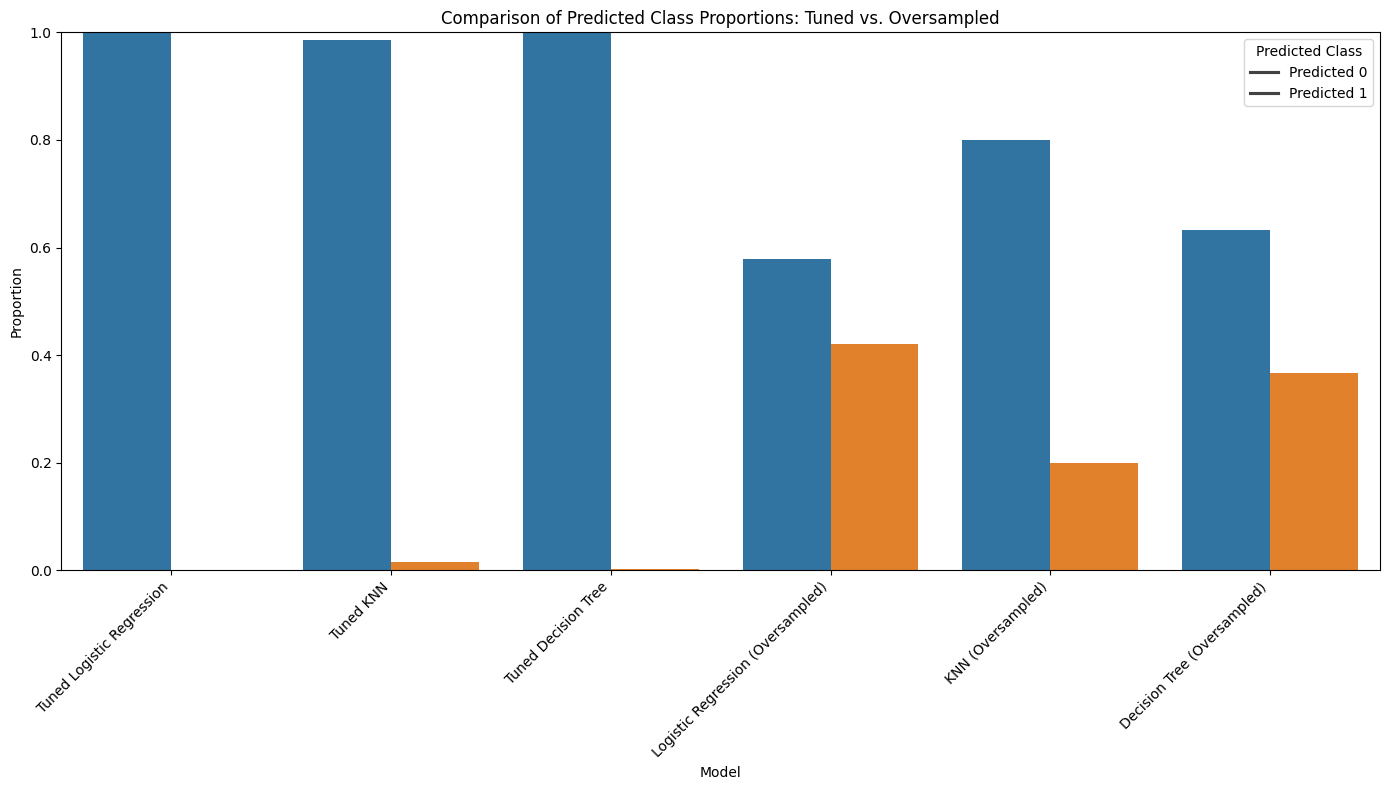

In [ ]:


# Create DataFrames of predicted proportions
tuned_proportions_df = pd.DataFrame({
    'Tuned Logistic Regression': pd.Series(y_test_pred_tuned_log_reg).value_counts(normalize=True).round(3),
    'Tuned KNN': pd.Series(y_test_pred_tuned_knn).value_counts(normalize=True).round(3),
    'Tuned Decision Tree': pd.Series(y_test_pred_tuned_dt).value_counts(normalize=True).round(3),

}).T.reset_index()
tuned_proportions_df.columns = ['Model', 'Predicted_0_Proportion', 'Predicted_1_Proportion']
tuned_proportions_df['Scenario'] = 'Tuned'


oversampled_proportions_dict = {
    'Logistic Regression (Oversampled)': pd.Series(y_test_pred_log_reg_resampled_over).value_counts(normalize=True).round(3),
    'KNN (Oversampled)': pd.Series(y_test_pred_knn_resampled_over).value_counts(normalize=True).round(3),
    'Decision Tree (Oversampled)': pd.Series(y_test_pred_dt_resampled_over).value_counts(normalize=True).round(3),
}




oversampled_proportions_df = pd.DataFrame(oversampled_proportions_dict).T.reset_index()
oversampled_proportions_df.columns = ['Model', 'Predicted_0_Proportion', 'Predicted_1_Proportion']
oversampled_proportions_df['Scenario'] = 'Oversampled'


# Combine the DataFrames
combined_proportions_df = pd.concat([tuned_proportions_df, oversampled_proportions_df], ignore_index=True)

# Melt the DataFrame to prepare for plotting
combined_proportions_melted = combined_proportions_df.melt(id_vars=['Model', 'Scenario'],
                                                           value_vars=['Predicted_0_Proportion', 'Predicted_1_Proportion'],
                                                           var_name='Predicted_Class', value_name='Proportion')

# Create grouped bar plot
plt.figure(figsize=(14, 8))
sns.barplot(x='Model', y='Proportion', hue='Predicted_Class', data=combined_proportions_melted)
plt.title('Comparison of Predicted Class Proportions: Tuned vs. Oversampled')
plt.ylabel('Proportion')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Predicted Class', labels=['Predicted 0', 'Predicted 1'])
plt.tight_layout()
plt.show()





### Summary of Findings:

After training and evaluating various models (Logistic Regression, KNN, Decision Tree, and SVM) under different scenarios (initial, hyperparameter tuned, oversampled training data, and undersampled training data), we can summarize the key findings based on the performance metrics (Accuracy, Precision, Recall, F1-score, and ROC AUC):

1.  **Initial Models**: The initial models, particularly Logistic Regression and SVM, showed high overall accuracy but struggled significantly with identifying the minority class (subscribers), as evidenced by very low Recall and F1-scores. This was primarily due to the class imbalance in the dataset.
2.  **Hyperparameter Tuning**: Hyperparameter tuning with a focus on ROC AUC led to some improvements in performance metrics for the tuned models compared to their initial counterparts, but the impact on metrics like Recall and F1-score for the minority class was still limited. The distribution of predicted classes remained heavily skewed towards the majority class for some models.
3.  **Oversampling**: Training models on oversampled data generally led to a significant increase in the prediction of the minority class, as seen in the distribution of predicted 'y' values. This often resulted in higher Recall scores, indicating a better ability to identify actual subscribers. However, this might come at the cost of Precision (more false positives) and potentially lower overall Accuracy compared to the baseline.
4.  **Undersampling**: Training models on undersampled data also aimed to balance the class distribution.

### Choosing the Best Model:

The "best" model or approach depends heavily on the specific business objective.

*   If the goal is to identify as many potential subscribers as possible, even if it means contacting some non-subscribers (prioritizing **Recall**), models trained on oversampled data or those with higher Recall scores would be preferred.
*   If the goal is to ensure that when the model predicts a subscription, it is highly likely to be correct (prioritizing **Precision**), models with higher Precision scores would be better.
*   The **F1-score** provides a balance between Precision and Recall. A higher F1-score indicates a better overall performance in handling the trade-off between these two metrics for the minority class.
*   **ROC AUC** is a good overall measure of the model's ability to discriminate between the two classes.

Looking at the visualizations and the specific values of the metrics (especially F1-score and ROC AUC for the tuned and resampled models). We can consider the trade-offs between identifying more potential subscribers (Recall) and minimizing wasted marketing efforts on non-subscribers (Precision).

